In [1]:
### Cell 0 — Imports & Setup


import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LearningRateScheduler
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings("ignore")
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

os.makedirs("outputs/plots",   exist_ok=True)
os.makedirs("outputs/models",  exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)
os.makedirs("deploy",          exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"Directories : ready")


TensorFlow  : 2.21.0
Directories : ready


In [ ]:
### Cell 1 — Data Loading


# UPDATE CSV_PATH to your actual file location

CSV_PATH = r"D:\AI & ML\DATA SCIENCE\PROJECTS\PROJECT 2.0\New folder\DATASET\RELIANCE.csv"
-

def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\n\nCSV not found: '{path}'\n"
            f"Windows: CSV_PATH = r'C:\\Users\\you\\Downloads\\RELIANCE.csv'\n"
            f"Colab  : CSV_PATH = '/content/RELIANCE.csv'\n"
        )
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Volume"] = df["Volume"].replace(0, np.nan)
    df.dropna(inplace=True)
    assert df.index.is_monotonic_increasing, "Dates not sorted!"
    assert df.duplicated().sum() == 0,       "Duplicate rows found!"
    print(f"  Rows       : {len(df):,}")
    print(f"  Date range : {df.index[0].date()} to {df.index[-1].date()}")
    print(f"  Last Close : Rs.{df['Close'].iloc[-1]:.2f}")
    return df

df = load_data(CSV_PATH)


  Rows       : 7,459
  Date range : 1996-01-01 to 2026-03-09
  Last Close : Rs.1399.50


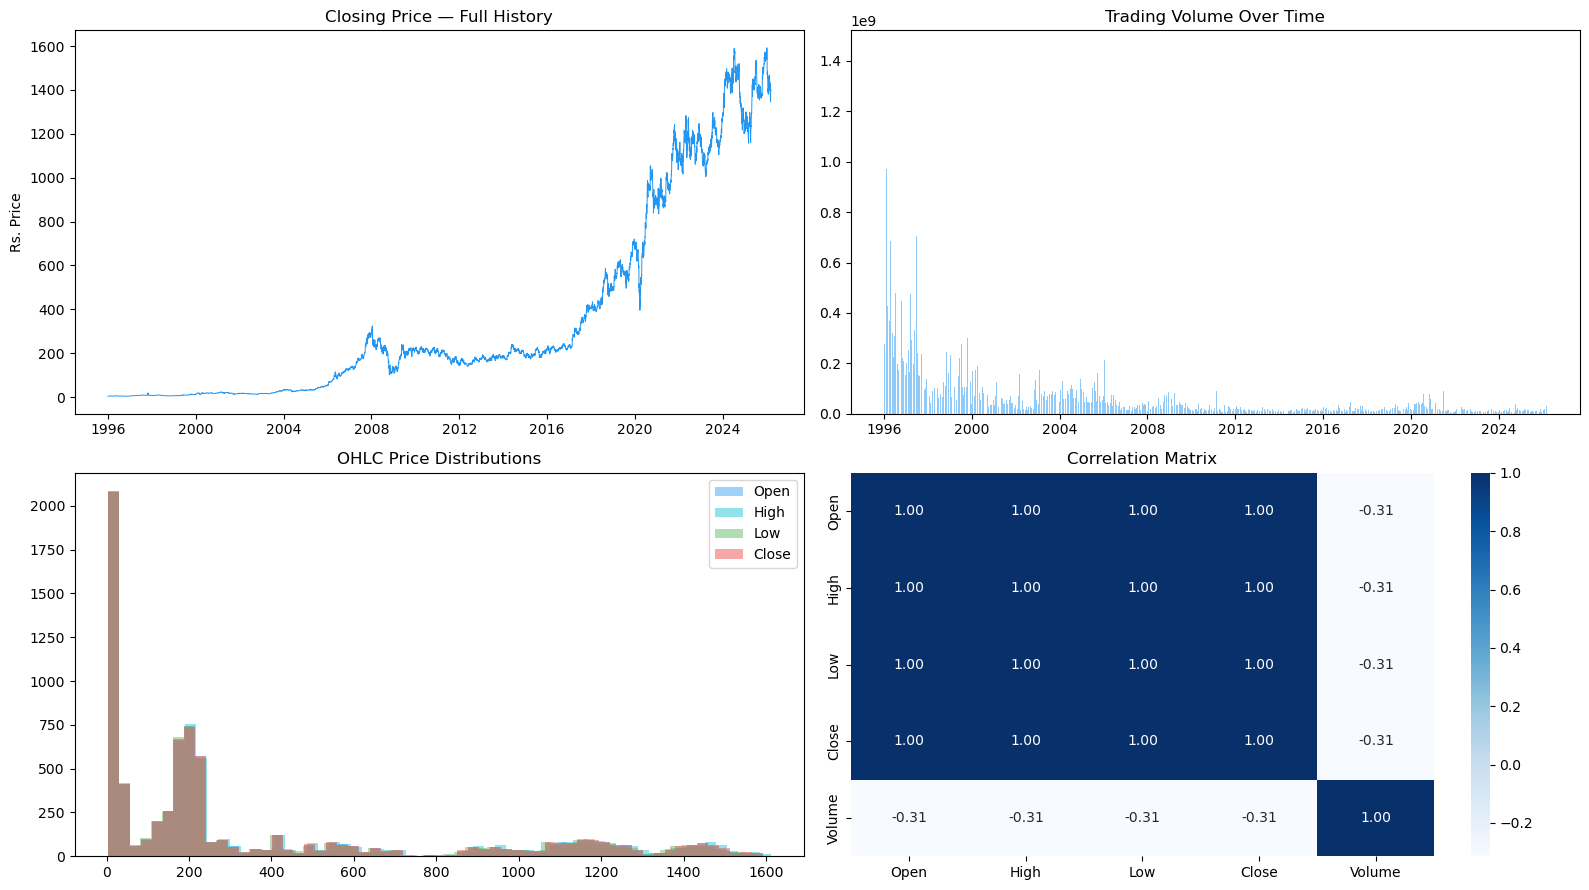

In [3]:
### Cell 2 — EDA Plots


fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0,0].plot(df["Close"], color="#2196F3", linewidth=0.7)
axes[0,0].set_title("Closing Price — Full History"); axes[0,0].set_ylabel("Rs. Price")
axes[0,1].bar(df.index, df["Volume"], color="#90CAF9", width=1.0)
axes[0,1].set_title("Trading Volume Over Time")
for col, color in zip(["Open","High","Low","Close"],
                      ["#42A5F5","#26C6DA","#66BB6A","#EF5350"]):
    axes[1,0].hist(df[col], bins=60, alpha=0.5, label=col, color=color)
axes[1,0].set_title("OHLC Price Distributions"); axes[1,0].legend()
# FIX: numeric_only=True required in pandas >= 2.0
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f", ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/plots/01_eda_overview.png", dpi=150)
plt.show()


In [4]:
### Cell 3 — Feature Engineering

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Return"]      = df["Close"].pct_change()
    df["Log_Return"]  = np.log(df["Close"] / df["Close"].shift(1))
    df["HL_Ratio"]    = (df["High"] - df["Low"]) / df["Close"]
    df["OC_Ratio"]    = (df["Close"] - df["Open"]) / df["Open"]
    df["Momentum_5"]  = df["Close"] - df["Close"].shift(5)
    df["Momentum_10"] = df["Close"] - df["Close"].shift(10)
    df["Vol_10"]      = df["Return"].rolling(10).std()
    df["MA5"]         = df["Close"].rolling(5).mean()
    df["MA20"]        = df["Close"].rolling(20).mean()
    df["MA_Ratio"]    = df["MA5"] / df["MA20"]
    df.drop(columns=["MA5", "MA20"], inplace=True)
    df["Log_Volume"]  = np.log(df["Volume"].clip(lower=1))
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

df = add_features(df)
print(f"Shape: {df.shape}  |  Columns: {list(df.columns)}")


Shape: (7440, 14)  |  Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Log_Return', 'HL_Ratio', 'OC_Ratio', 'Momentum_5', 'Momentum_10', 'Vol_10', 'MA_Ratio', 'Log_Volume']


In [5]:
### Cell 4 — Feature & Target Config

TARGET_COL   = "Log_Return"
SEQUENCE_LEN = 60

FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "HL_Ratio", "OC_Ratio",
    "Momentum_5", "Momentum_10",
    "Vol_10", "MA_Ratio", "Log_Volume"
]

N_FEATURES = len(FEATURE_COLS)
print(f"Features ({N_FEATURES}): {FEATURE_COLS}")
print(f"Target              : {TARGET_COL}")


Features (13): ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'HL_Ratio', 'OC_Ratio', 'Momentum_5', 'Momentum_10', 'Vol_10', 'MA_Ratio', 'Log_Volume']
Target              : Log_Return


In [6]:
### Cell 5 — Walk-Forward Splits

def walk_forward_splits(df, n_train_folds=4, val_frac=0.15, seq_len=60):
    """
    Fixed: reserves 15% of training era as val pool so Fold 4 always has
    enough validation rows (original bug: train_end == n_data -> 0 val rows).
    """
    n          = len(df)
    test_start = int(n * (1 - val_frac))
    test_df    = df.iloc[test_start - seq_len:]
    data_df    = df.iloc[:test_start]
    n_data     = len(data_df)

    val_pool_frac = 0.15
    val_chunk     = int(n_data * val_pool_frac)
    train_budget  = n_data - val_chunk
    fold_size     = train_budget // n_train_folds
    MIN_VAL       = seq_len + 30
    splits        = []

    for fold in range(1, n_train_folds + 1):
        train_end = fold * fold_size
        val_start = train_end - seq_len
        val_end   = min(train_end + val_chunk, n_data)
        train     = data_df.iloc[:train_end]
        val       = data_df.iloc[val_start:val_end]
        val_rows  = len(val)
        if val_rows < MIN_VAL:
            print(f"  WARNING Fold {fold}: val too small ({val_rows}) — skipped")
            continue
        splits.append((fold, train, val))
        print(f"  Fold {fold}: Train {train.index[0].date()} to "
              f"{train.index[-1].date()} ({len(train):,}) | "
              f"Val {val.index[seq_len].date()} to "
              f"{val.index[-1].date()} ({val_rows - seq_len:,})")

    print(f"\n  Test: {test_df.index[seq_len].date()} to "
          f"{test_df.index[-1].date()} ({len(test_df) - seq_len:,} rows)")

    assert len(splits) == n_train_folds, (
        f"Only {len(splits)}/{n_train_folds} folds. Reduce val_pool_frac and retry."
    )
    return splits, test_df

splits, test_df = walk_forward_splits(df, n_train_folds=4, val_frac=0.15, seq_len=SEQUENCE_LEN)


  Fold 1: Train 1996-01-29 to 2001-07-02 (1,344) | Val 2001-07-03 to 2005-04-18 (948)
  Fold 2: Train 1996-01-29 to 2006-11-21 (2,688) | Val 2006-11-22 to 2010-09-30 (948)
  Fold 3: Train 1996-01-29 to 2012-05-09 (4,032) | Val 2012-05-10 to 2016-03-18 (948)
  Fold 4: Train 1996-01-29 to 2017-10-27 (5,376) | Val 2017-10-30 to 2021-08-31 (948)

  Test: 2021-09-01 to 2026-03-09 (1,116 rows)


In [7]:
### Cell 6 — Sequence Builder & Preprocessor

def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len : i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def preprocess_split(train_df, val_df, feature_cols, target_col, seq_len):
    # RobustScaler for features: handles 30-year price skew (Rs.3 to Rs.1600)
    # StandardScaler for target: log-return is approximately normal
    # Both scalers fit ONLY on train to prevent lookahead bias
    f_scaler = RobustScaler()
    t_scaler = StandardScaler()
    X_tr_raw = f_scaler.fit_transform(train_df[feature_cols])
    X_va_raw = f_scaler.transform(val_df[feature_cols])
    y_tr_raw = t_scaler.fit_transform(train_df[[target_col]])
    y_va_raw = t_scaler.transform(val_df[[target_col]])
    X_tr, y_tr = make_sequences(X_tr_raw, y_tr_raw, seq_len)
    X_va, y_va = make_sequences(X_va_raw, y_va_raw, seq_len)
    return X_tr, y_tr, X_va, y_va, f_scaler, t_scaler


In [8]:
### Cell 7 — Model Definition

class BahdanauAttention(layers.Layer):
    """
    Additive attention over T GRU hidden states.
    alpha weights reveal which past days drove each prediction.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, hidden_states):
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))
        score   = score - tf.reduce_max(score, axis=1, keepdims=True)
        alpha   = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * hidden_states, axis=1)
        return context, alpha

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg


def build_model(seq_len, n_features, gru1=160,gru2=96, attn_units=64,
                dense1=64, dense2=32, dropout=0.15, l2=5e-6):
    """
    Input(60,13) -> GRU(128)->LN -> GRU(64)->LN -> Attention -> Dense(64)->Dense(32) -> Output(1)
    l2=1e-5, recurrent_dropout=0.1 — fixed from 1e-4/0.2 which caused underfitting
    """
    reg    = regularizers.l2(l2)
    inputs = tf.keras.Input(shape=(seq_len, n_features), name="input")
    x = layers.GRU(gru1, return_sequences=True, dropout=dropout,
                   recurrent_dropout=0.1, kernel_regularizer=reg,
                   recurrent_regularizer=reg, kernel_initializer="he_normal",
                   name="gru_1")(inputs)
    x = layers.LayerNormalization(name="ln_1")(x)
    x = layers.GRU(gru2, return_sequences=True, dropout=dropout,
                   recurrent_dropout=0.1, kernel_regularizer=reg,
                   recurrent_regularizer=reg, kernel_initializer="he_normal",
                   name="gru_2")(x)
    x = layers.LayerNormalization(name="ln_2")(x)
    context, _ = BahdanauAttention(attn_units, name="attention")(x)
    x = layers.Dense(dense1, activation="relu",
                     kernel_regularizer=reg, name="dense_1")(context)
    x = layers.Dropout(dropout, name="drop_1")(x)
    x = layers.Dense(dense2, activation="relu",
                     kernel_regularizer=reg, name="dense_2")(x)
    x = layers.Dropout(dropout * 0.5, name="drop_2")(x)
    output = layers.Dense(1, name="output")(x)
    return Model(inputs, output, name="AttentionGRU_v2")


In [9]:
### Cell 8 — Training Loop + Save All Artifacts

WARMUP_EPOCHS = 5
INIT_LR       = 5e-5
PEAK_LR       = 8e-4


def warmup_schedule(epoch, lr):
    if epoch < WARMUP_EPOCHS:
        return float(INIT_LR + (PEAK_LR - INIT_LR) * (epoch / WARMUP_EPOCHS))
    return float(lr)


def train_fold(fold_num, train_df, val_df):
    print(f"\n{'='*60}\n  FOLD {fold_num}  | "
          f"Train: {len(train_df):,}  Val: {len(val_df)-SEQUENCE_LEN:,}\n{'='*60}")
    X_tr, y_tr, X_va, y_va, f_sc, t_sc = preprocess_split(
        train_df, val_df, FEATURE_COLS, TARGET_COL, SEQUENCE_LEN)
    model = build_model(SEQUENCE_LEN, N_FEATURES)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR, clipnorm=1.0),
        loss="huber", metrics=["mae"]
    )
    if fold_num == 1:
        model.summary()
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=35,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=12, min_lr=1e-7, verbose=0),
        ModelCheckpoint(f"outputs/models/fold_{fold_num}_best.keras",
                        monitor="val_loss", save_best_only=True, verbose=0),
        LearningRateScheduler(warmup_schedule, verbose=0),
    ]
    history = model.fit(
        X_tr, y_tr, validation_data=(X_va, y_va),
        epochs=150, batch_size=16,callbacks=callbacks, verbose=1)
    print(f"  Best val_loss: {min(history.history['val_loss']):.5f}")
    return model, history, f_sc, t_sc


# ── Train all 4 folds ──────────────────────────────────────────────────────
fold_results = []
for fold_num, train_df_fold, val_df_fold in splits:
    model_fold, history_fold, f_sc, t_sc = train_fold(fold_num, train_df_fold, val_df_fold)
    fold_results.append({
        "fold": fold_num, "model": model_fold, "history": history_fold,
        "f_scaler": f_sc, "t_scaler": t_sc,
        "train_df": train_df_fold, "val_df": val_df_fold,
    })

# ── UPDATED: select the fold with balanced fit ─────────────────────────────
# Good fit = |train_loss - val_loss| is minimal AND gap is small
# We score each fold by abs(min_train - min_val); lower is better balanced.
# This avoids both underfitting (train >> val) and overfitting (val >> train).
def _fit_score(r):
    min_train = min(r["history"].history["loss"])
    min_val   = min(r["history"].history["val_loss"])
    return abs(min_train - min_val)          # smaller = more balanced

best_result = min(fold_results, key=_fit_score)
_bt = min(best_result["history"].history["loss"])
_bv = min(best_result["history"].history["val_loss"])
print(f"\nBest fold selected: Fold {best_result['fold']}"
      f"  (most balanced fit — min_train={_bt:.5f}, min_val={_bv:.5f},"
      f" gap={abs(_bt-_bv):.5f})")

final_model = best_result["model"]
final_f_sc  = best_result["f_scaler"]
final_t_sc  = best_result["t_scaler"]
final_train = best_result["train_df"]

# ── SAVE 1: Model weights (.keras) ─────────────────────────────────────────
final_model.save("outputs/models/final_model.keras")
print("Saved: outputs/models/final_model.keras")

# ── SAVE 2: Feature scaler (.pkl) ──────────────────────────────────────────
joblib.dump(final_f_sc, "outputs/models/final_f_scaler.pkl")
print("Saved: outputs/models/final_f_scaler.pkl")

# ── SAVE 3: Target scaler (.pkl) ───────────────────────────────────────────
joblib.dump(final_t_sc, "outputs/models/final_t_scaler.pkl")
print("Saved: outputs/models/final_t_scaler.pkl")

# ── SAVE 4: Model config JSON (everything needed to reload + run inference) ─
model_config = {
    "model_name"      : "AttentionGRU_v2",
    "sequence_len"    : SEQUENCE_LEN,
    "n_features"      : N_FEATURES,
    "feature_cols"    : FEATURE_COLS,
    "target_col"      : TARGET_COL,
    "trained_on_fold" : int(best_result["fold"]),
    "train_end_date"  : str(final_train.index[-1].date()),
    "architecture": {
        "gru1": 160, "gru2": 96, "attn_units": 64,
        "dense1": 64, "dense2": 32, "dropout": 0.15,
        "l2": 5e-6, "recurrent_dropout": 0.05
    },
    "training": {
        "loss": "huber", "optimizer": "adam",
        "init_lr": INIT_LR, "peak_lr": PEAK_LR,
        "warmup_epochs": WARMUP_EPOCHS,
        "batch_size": 16, "max_epochs": 150,
        "early_stopping_patience": 35
    }
}
with open("outputs/models/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print("Saved: outputs/models/model_config.json")

print(f"\nAll artifacts saved. Best fold = {best_result['fold']}, "
      f"trained up to {final_train.index[-1].date()}")



  FOLD 1  | Train: 1,344  Val: 948



Model: "AttentionGRU_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 160)        │        84,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (None, 60, 160)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 60, 96)         │        74,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (None, 60, 96)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 96), (None,    │         6,273 │
│                                 │ 60, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,410 (677.38 KB)

 Trainable params: 173,410 (677.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.3693 - mae: 0.7050 - val_loss: 0.1520 - val_mae: 0.4138 - learning_rate: 5.0000e-05
Epoch 2/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.3122 - mae: 0.6253 - val_loss: 0.1512 - val_mae: 0.4088 - learning_rate: 2.0000e-04
Epoch 3/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.2939 - mae: 0.6004 - val_loss: 0.1415 - val_mae: 0.3964 - learning_rate: 3.5000e-04
Epoch 4/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.2821 - mae: 0.5810 - val_loss: 0.1405 - val_mae: 0.3936 - learning_rate: 5.0000e-04
Epoch 5/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.2799 - mae: 0.5770 - val_loss: 0.1397 - val_mae: 0.3927 - learning_rate: 6.5000e-04
Epoch 6/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.2738 - mae: 0.5672 - val_loss: 0.1418 - val_mae: 0.3981 - learning_rate: 6.5000e-04
Epoch 7/150
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.2726 - mae: 0.5638 - val_loss: 0.1398 - val_mae: 0.3936 - lea

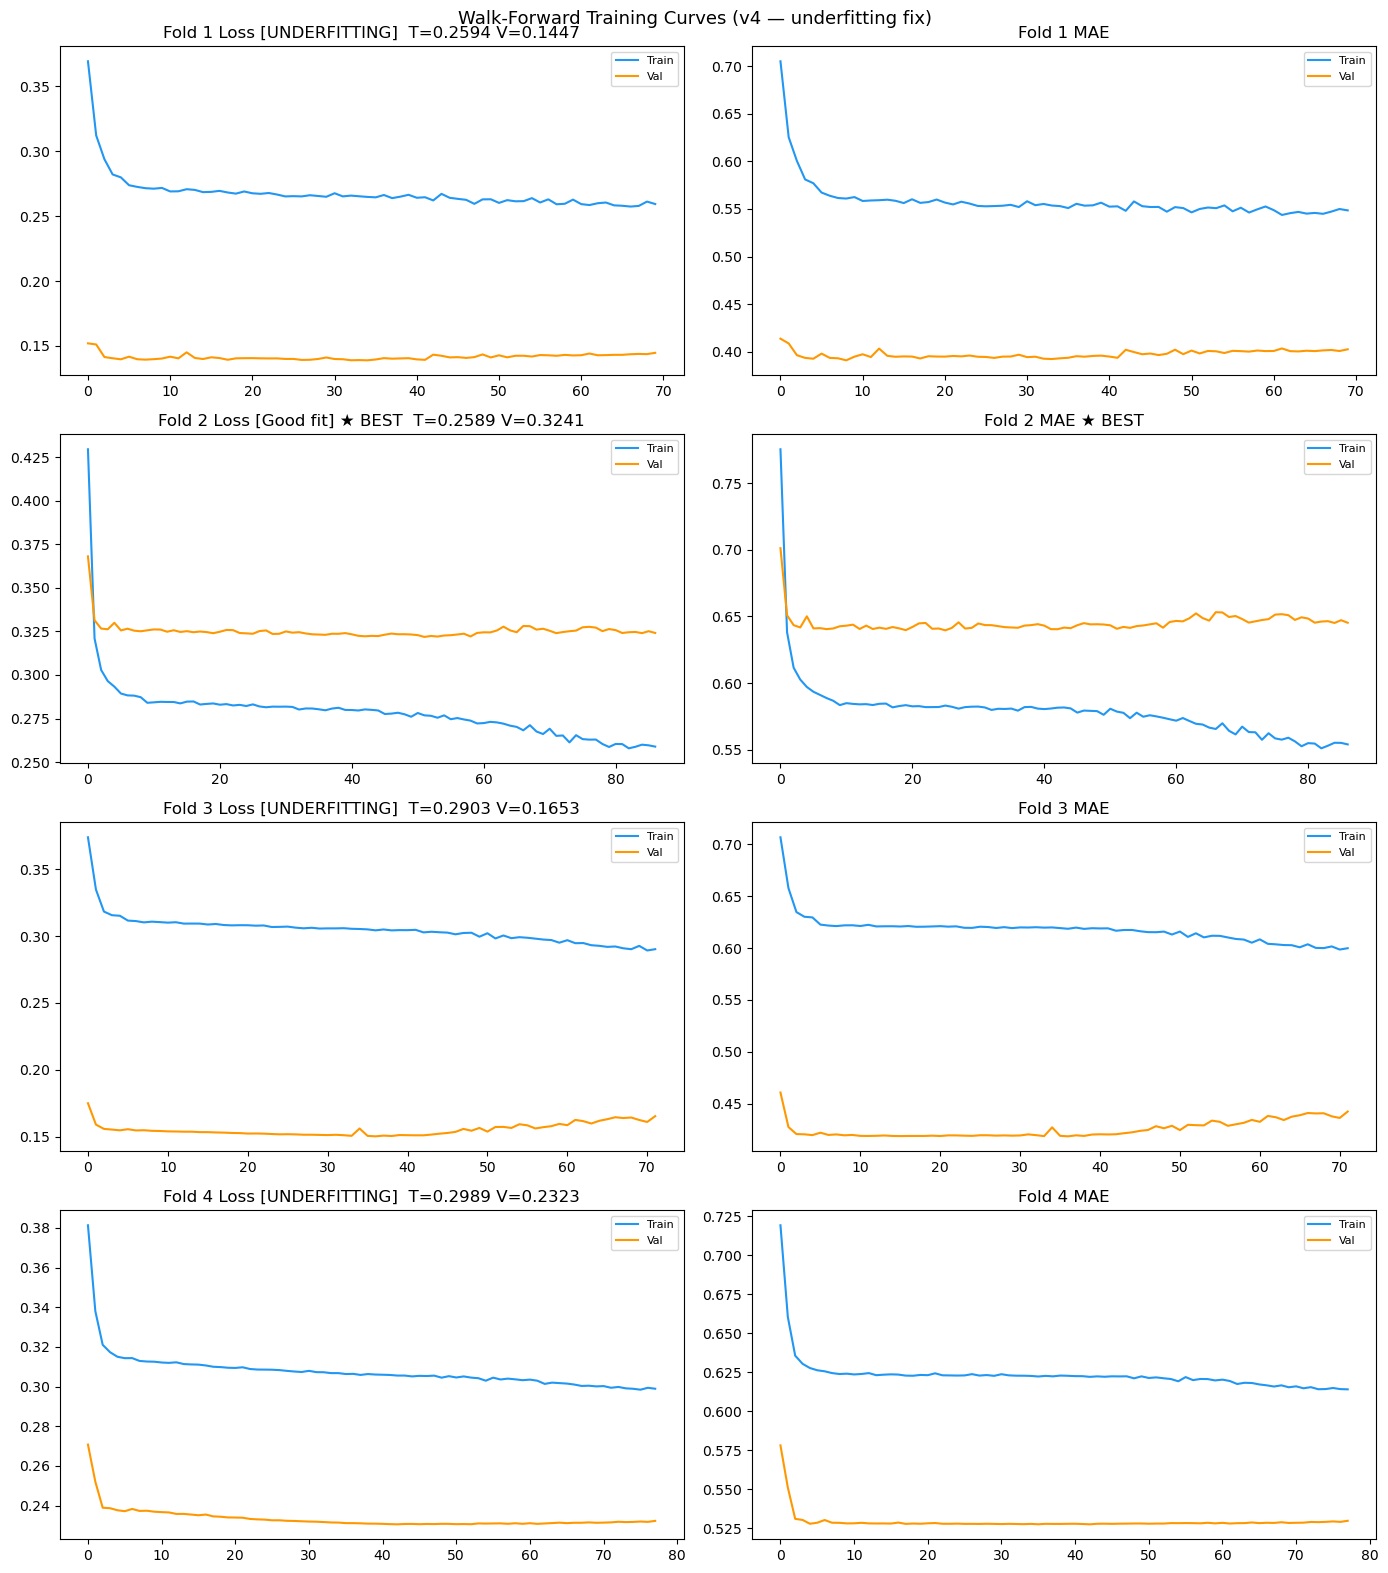

In [10]:
### Cell 9 — Training Curves

n_folds = len(fold_results)
fig, axes = plt.subplots(n_folds, 2, figsize=(14, 4 * n_folds))
for i, res in enumerate(fold_results):
    h    = res["history"].history
    fold = res["fold"]
    t_loss = h["loss"][-1]; v_loss = h["val_loss"][-1]
    if   t_loss < v_loss * 0.75: status = "OVERFITTING"
    elif t_loss > v_loss * 1.10: status = "UNDERFITTING"
    else:                         status = "Good fit"
    star = " ★ BEST" if res["fold"] == best_result["fold"] else ""
    axes[i,0].plot(h["loss"],     label="Train", color="#2196F3")
    axes[i,0].plot(h["val_loss"], label="Val",   color="#FF9800")
    axes[i,0].set_title(f"Fold {fold} Loss [{status}]{star}  T={t_loss:.4f} V={v_loss:.4f}")
    axes[i,0].legend(fontsize=8)
    axes[i,1].plot(h["mae"],     label="Train", color="#2196F3")
    axes[i,1].plot(h["val_mae"], label="Val",   color="#FF9800")
    axes[i,1].set_title(f"Fold {fold} MAE{star}"); axes[i,1].legend(fontsize=8)
plt.suptitle("Walk-Forward Training Curves (v4 — underfitting fix)", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/04_fold_training_curves.png", dpi=150)
plt.show()


In [11]:
### Cell 10 — Overfitting / Underfitting Diagnostics

# Run this immediately after Cell 9 to confirm the fixes worked.
# Target: all folds should show status = "Good fit" (train ≈ val ±10%)
print("-- Fit Diagnostics (v4) --")
print(f"{'Fold':<6} {'train':>8} {'val':>8} {'gap':>8}  Status")
print("-" * 60)
for res in fold_results:
    h    = res["history"].history
    fold = res["fold"]
    mtr  = min(h["loss"]); mva = min(h["val_loss"])
    gap  = mva - mtr
    if   mtr < mva * 0.75: status = "OVERFITTING  → increase dropout/L2"
    elif mtr > mva * 1.10: status = "UNDERFITTING → decrease L2/recurrent_dropout further"
    else:                   status = "Good generalisation ✓"
    best = " ★" if res["fold"] == best_result["fold"] else ""
    print(f"  {fold:<4} {mtr:>8.4f} {mva:>8.4f} {gap:>+8.4f}  {status}{best}")


-- Fit Diagnostics (v4) --
Fold      train      val      gap  Status
------------------------------------------------------------
  1      0.2574   0.1389  -0.1185  UNDERFITTING → decrease L2/recurrent_dropout further
  2      0.2579   0.3218  +0.0639  Good generalisation ✓ ★
  3      0.2893   0.1502  -0.1390  UNDERFITTING → decrease L2/recurrent_dropout further
  4      0.2985   0.2306  -0.0679  UNDERFITTING → decrease L2/recurrent_dropout further


In [12]:
### Cell 11 — Evaluation Helpers


def directional_accuracy(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)) * 100)


def reconstruct_price_rolling(lr_true, lr_pred, anchor_prices, reset_every=20):
    n = len(lr_true)
    prices_true = np.zeros(n); prices_pred = np.zeros(n)
    for i in range(n):
        if i % reset_every == 0:
            anchor = anchor_prices[i]
        start = i - (i % reset_every)
        prices_true[i] = anchor * np.exp(np.sum(lr_true[start:i+1]))
        prices_pred[i] = anchor * np.exp(np.sum(lr_pred[start:i+1]))
    return prices_true, prices_pred


def evaluate(model, X, y_scaled, t_scaler, anchor_series, label, reset_every=20):
    y_pred_s  = model.predict(X, verbose=0)
    y_pred_lr = t_scaler.inverse_transform(y_pred_s).flatten()
    y_true_lr = t_scaler.inverse_transform(y_scaled).flatten()
    y_true_p, y_pred_p = reconstruct_price_rolling(
        y_true_lr, y_pred_lr, anchor_series.values, reset_every)
    mae  = mean_absolute_error(y_true_p, y_pred_p)
    rmse = np.sqrt(mean_squared_error(y_true_p, y_pred_p))
    mape = np.mean(np.abs((y_true_p - y_pred_p) / y_true_p)) * 100
    r2   = r2_score(y_true_p, y_pred_p)
    da   = directional_accuracy(y_true_lr, y_pred_lr)
    print(f"\n-- {label} --")
    print(f"  MAE: Rs.{mae:.2f}  RMSE: Rs.{rmse:.2f}  MAPE: {mape:.3f}%  R2: {r2:.4f}  DirAcc: {da:.1f}%")
    return y_true_p, y_pred_p, y_true_lr, y_pred_lr



-- Validation --
  MAE: Rs.11.13  RMSE: Rs.16.45  MAPE: 5.912%  R2: 0.8652  DirAcc: 51.1%

-- TEST — Unseen --
  MAE: Rs.46.18  RMSE: Rs.59.98  MAPE: 3.675%  R2: 0.8463  DirAcc: 51.7%


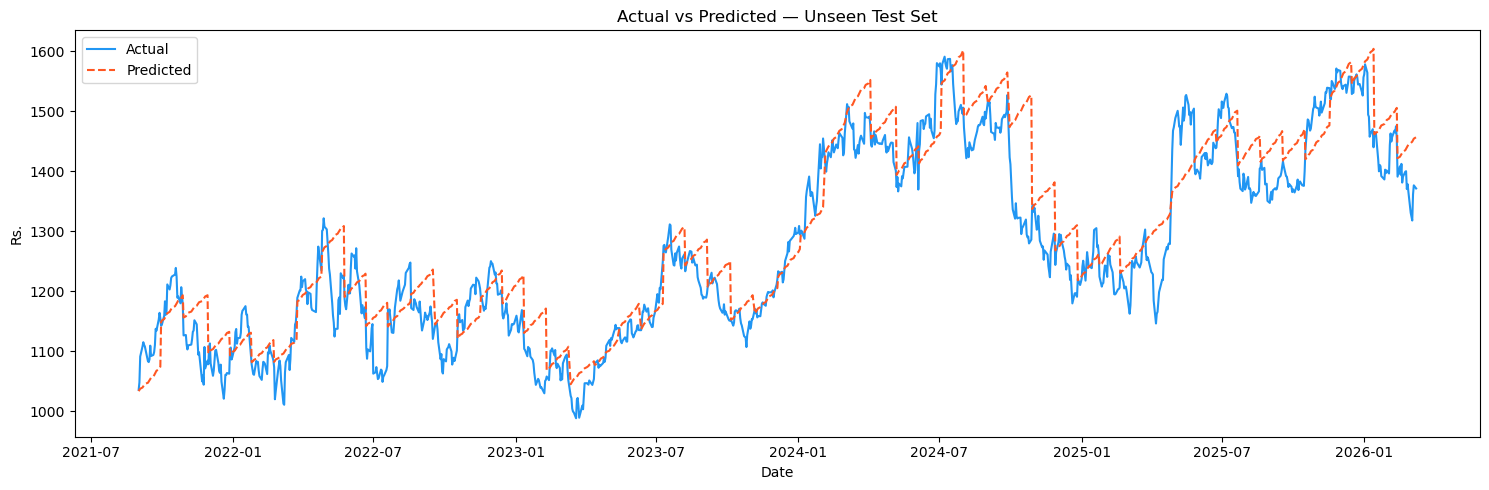

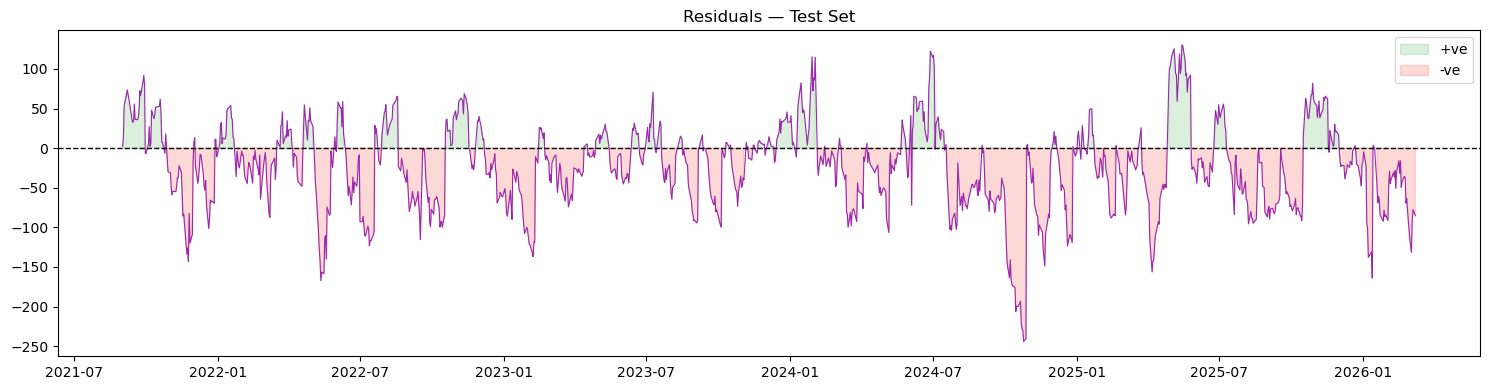

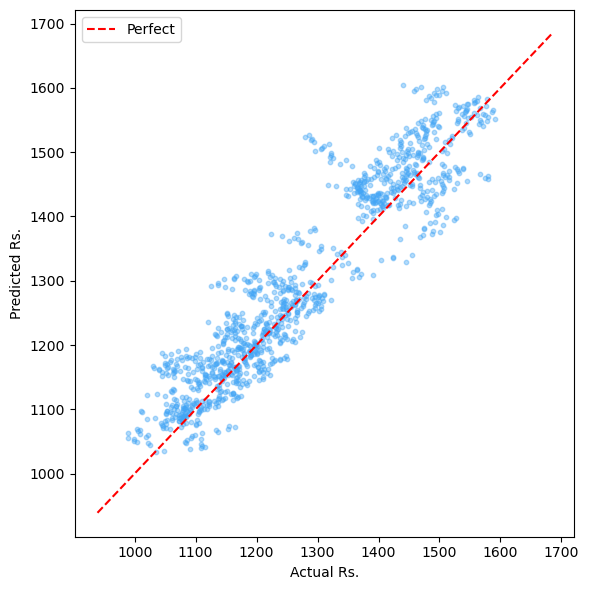

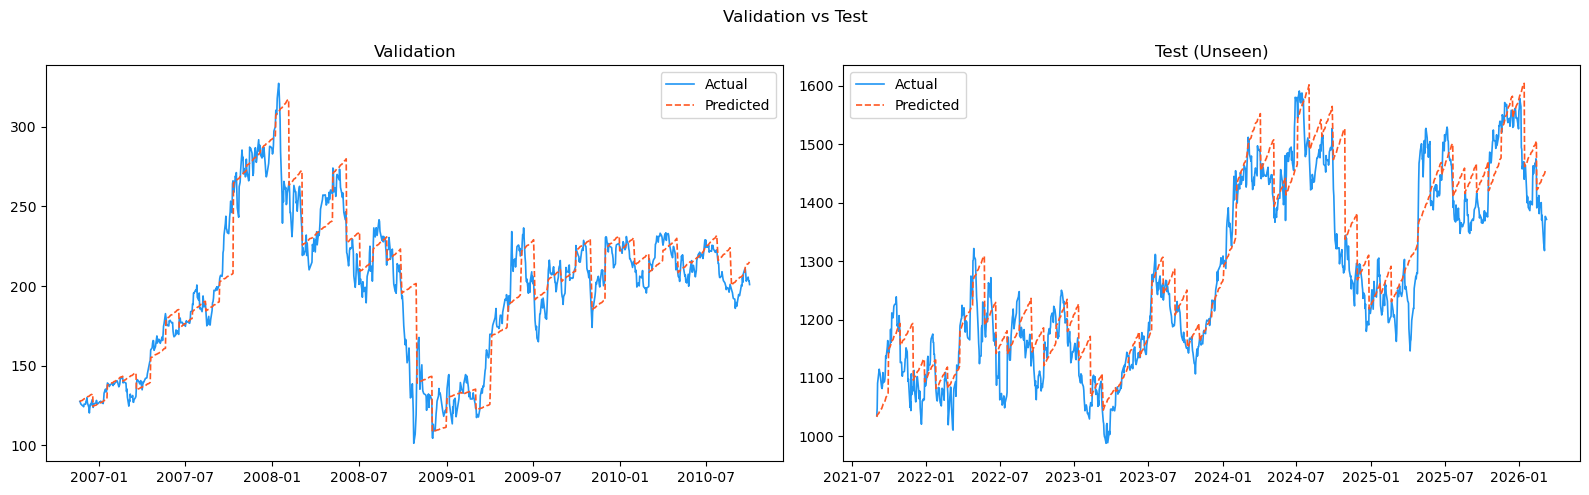

In [13]:
### Cell 12 — Test Evaluation + Plots


X_test_raw = final_f_sc.transform(test_df[FEATURE_COLS])
y_test_raw = final_t_sc.transform(test_df[[TARGET_COL]])
X_test, y_test = make_sequences(X_test_raw, y_test_raw, SEQUENCE_LEN)
test_dates         = test_df.index[SEQUENCE_LEN:]
test_anchor_series = test_df["Close"].iloc[SEQUENCE_LEN:].reset_index(drop=True)

last_val_df       = best_result["val_df"]
X_val_raw         = final_f_sc.transform(last_val_df[FEATURE_COLS])
y_val_raw         = final_t_sc.transform(last_val_df[[TARGET_COL]])
X_val, y_val      = make_sequences(X_val_raw, y_val_raw, SEQUENCE_LEN)
val_dates         = last_val_df.index[SEQUENCE_LEN:]
val_anchor_series = last_val_df["Close"].iloc[SEQUENCE_LEN:].reset_index(drop=True)

print("=" * 62)
y_val_true,  y_val_pred,  val_lr_true,  val_lr_pred  = evaluate(
    final_model, X_val,  y_val,  final_t_sc, val_anchor_series, "Validation")
print("=" * 62)
y_test_true, y_test_pred, test_lr_true, test_lr_pred = evaluate(
    final_model, X_test, y_test, final_t_sc, test_anchor_series, "TEST — Unseen")
print("=" * 62)

# Plot 1 — Actual vs Predicted
plt.figure(figsize=(15,5))
plt.plot(test_dates, y_test_true, label="Actual",    color="#2196F3", lw=1.5)
plt.plot(test_dates, y_test_pred, label="Predicted", color="#FF5722", lw=1.5, ls="--")
plt.title("Actual vs Predicted — Unseen Test Set")
plt.xlabel("Date"); plt.ylabel("Rs."); plt.legend()
plt.tight_layout(); plt.savefig("outputs/plots/06_test_actual_vs_predicted.png", dpi=150); plt.show()

# Plot 2 — Residuals
residuals = y_test_true - y_test_pred
plt.figure(figsize=(15,4))
plt.plot(test_dates, residuals, color="#9C27B0", lw=0.8)
plt.axhline(0, color="black", lw=1.0, ls="--")
plt.fill_between(test_dates, residuals, 0, where=(residuals>0), alpha=0.2, color="#4CAF50", label="+ve")
plt.fill_between(test_dates, residuals, 0, where=(residuals<0), alpha=0.2, color="#F44336", label="-ve")
plt.title("Residuals — Test Set"); plt.legend()
plt.tight_layout(); plt.savefig("outputs/plots/07_residuals.png", dpi=150); plt.show()

# Plot 3 — Scatter
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.4, color="#42A5F5", s=10)
lim = [min(y_test_true.min(), y_test_pred.min())*0.95,
       max(y_test_true.max(), y_test_pred.max())*1.05]
plt.plot(lim, lim, "r--", lw=1.5, label="Perfect")
plt.xlabel("Actual Rs."); plt.ylabel("Predicted Rs."); plt.legend()
plt.tight_layout(); plt.savefig("outputs/plots/08_scatter.png", dpi=150); plt.show()

# Plot 4 — Val vs Test
fig, axes = plt.subplots(1, 2, figsize=(16,5))
axes[0].plot(val_dates, y_val_true, label="Actual", color="#2196F3", lw=1.2)
axes[0].plot(val_dates, y_val_pred, label="Predicted", color="#FF5722", lw=1.2, ls="--")
axes[0].set_title("Validation"); axes[0].legend()
axes[1].plot(test_dates, y_test_true, label="Actual", color="#2196F3", lw=1.2)
axes[1].plot(test_dates, y_test_pred, label="Predicted", color="#FF5722", lw=1.2, ls="--")
axes[1].set_title("Test (Unseen)"); axes[1].legend()
plt.suptitle("Validation vs Test"); plt.tight_layout()
plt.savefig("outputs/plots/09_val_vs_test.png", dpi=150); plt.show()


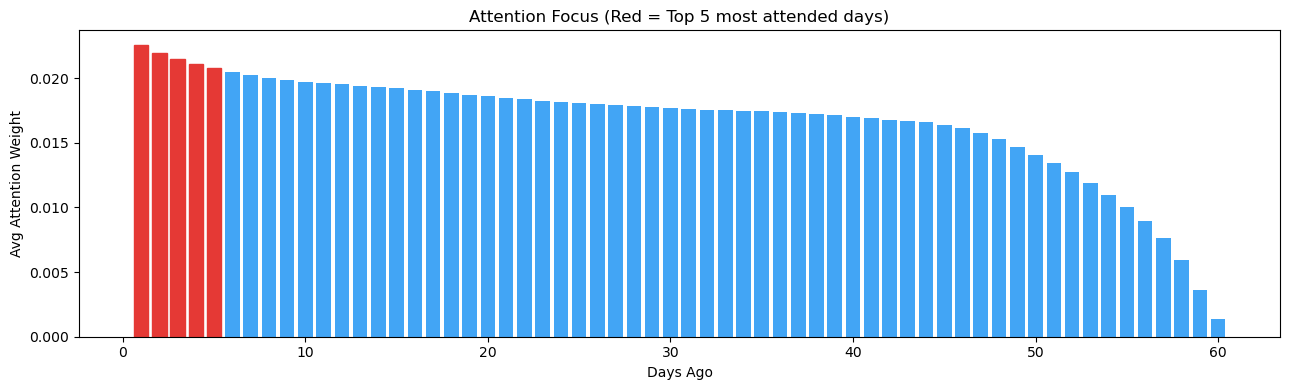

Top-5 attended days ago: [1, 2, 3, 4, 5]


In [14]:
### Cell 13 — Attention Weights


attn_extractor = Model(
    inputs=final_model.input,
    outputs=[final_model.output, final_model.get_layer("attention").output[1]]
)
_, attn_weights = attn_extractor.predict(X_test, verbose=0)
avg_attn = attn_weights.mean(axis=0).flatten()
days_ago = list(range(SEQUENCE_LEN, 0, -1))
plt.figure(figsize=(13,4))
bars = plt.bar(days_ago, avg_attn, color="#42A5F5")
top5_idx = np.argsort(avg_attn)[-5:]
for idx in top5_idx:
    bars[idx].set_color("#E53935")
plt.xlabel("Days Ago"); plt.ylabel("Avg Attention Weight")
plt.title("Attention Focus (Red = Top 5 most attended days)")
plt.tight_layout(); plt.savefig("outputs/plots/10_attention_weights.png", dpi=150); plt.show()
top5 = sorted([days_ago[i] for i in top5_idx])
print(f"Top-5 attended days ago: {top5}")



-- Fold 1 --
  MAE: Rs.1.15  RMSE: Rs.1.65  MAPE: 5.174%  R2: 0.9516  DirAcc: 48.9%

-- Fold 2 --
  MAE: Rs.11.13  RMSE: Rs.16.45  MAPE: 5.912%  R2: 0.8652  DirAcc: 51.1%

-- Fold 3 --
  MAE: Rs.6.99  RMSE: Rs.9.36  MAPE: 3.670%  R2: 0.8086  DirAcc: 52.4%

-- Fold 4 --
  MAE: Rs.31.46  RMSE: Rs.43.85  MAPE: 4.846%  R2: 0.9534  DirAcc: 52.1%

-- Per-Fold Metrics --
 Fold  MAPE_pct     R2  DirAcc BestFold
    1     5.174 0.9516   48.95         
    2     5.912 0.8652   51.05        ★
    3     3.670 0.8086   52.43         
    4     4.846 0.9534   52.11         

-- Test Set --  MAE=Rs.46.18  RMSE=Rs.59.98  MAPE=3.675%  R2=0.8463  DA=51.7%
Saved: outputs/results/metrics_summary.csv


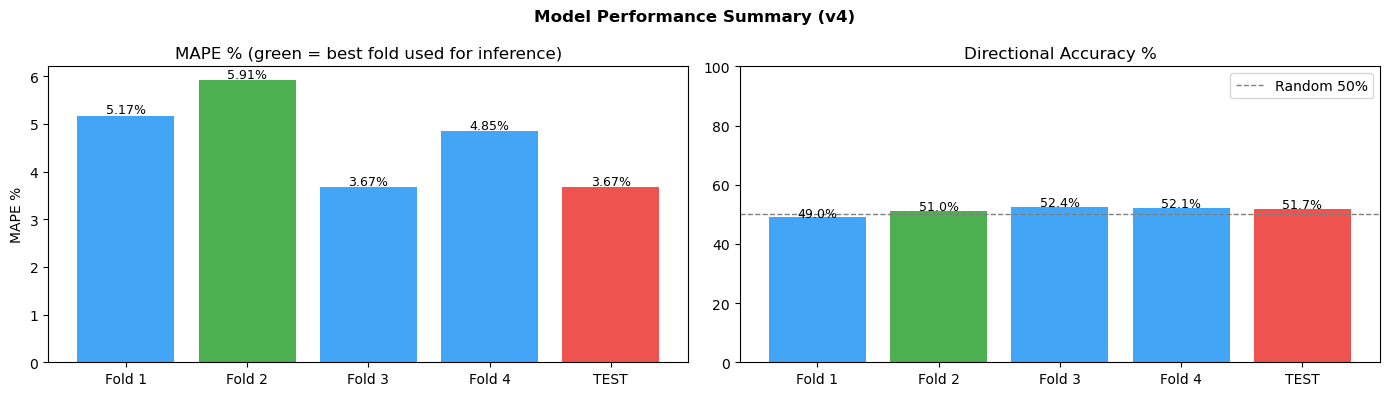

In [15]:
### Cell 14 — Per-Fold Metrics + Save CSV


fold_metrics = []
for res in fold_results:
    Xv_raw = res["f_scaler"].transform(res["val_df"][FEATURE_COLS])
    yv_raw = res["t_scaler"].transform(res["val_df"][[TARGET_COL]])
    Xv, yv = make_sequences(Xv_raw, yv_raw, SEQUENCE_LEN)
    anc    = res["val_df"]["Close"].iloc[SEQUENCE_LEN:].reset_index(drop=True)
    yt, yp, lr_t, lr_p = evaluate(res["model"], Xv, yv, res["t_scaler"], anc, f"Fold {res['fold']}")
    fold_metrics.append({
        "Fold"    : res["fold"],
        "MAPE_pct": round(np.mean(np.abs((yt-yp)/yt))*100, 3),
        "R2"      : round(r2_score(yt, yp), 4),
        "DirAcc"  : round(directional_accuracy(lr_t, lr_p), 2),
        "BestFold": "★" if res["fold"] == best_result["fold"] else "",
    })

test_mape = round(np.mean(np.abs((y_test_true-y_test_pred)/y_test_true))*100, 3)
test_r2   = round(r2_score(y_test_true, y_test_pred), 4)
test_mae  = round(mean_absolute_error(y_test_true, y_test_pred), 2)
test_rmse = round(np.sqrt(mean_squared_error(y_test_true, y_test_pred)), 2)
test_da   = round(directional_accuracy(test_lr_true, test_lr_pred), 2)

print("\n-- Per-Fold Metrics --")
print(pd.DataFrame(fold_metrics).to_string(index=False))
print(f"\n-- Test Set --  MAE=Rs.{test_mae}  RMSE=Rs.{test_rmse}  MAPE={test_mape}%  R2={test_r2}  DA={test_da}%")

summary = fold_metrics + [{"Fold":"TEST","MAPE_pct":test_mape,"R2":test_r2,"DirAcc":test_da,"BestFold":""}]
pd.DataFrame(summary).to_csv("outputs/results/metrics_summary.csv", index=False)
print("Saved: outputs/results/metrics_summary.csv")

labels = [f"Fold {r['Fold']}" for r in fold_metrics] + ["TEST"]
mapes  = [r["MAPE_pct"] for r in fold_metrics] + [test_mape]
das    = [r["DirAcc"]   for r in fold_metrics] + [test_da]
colors = ["#42A5F5"]*len(fold_metrics) + ["#EF5350"]
# Highlight the best fold in green
for i, res in enumerate(fold_results):
    if res["fold"] == best_result["fold"]:
        colors[i] = "#4CAF50"
fig, axes = plt.subplots(1, 2, figsize=(14,4))
bars = axes[0].bar(labels, mapes, color=colors)
for b, v in zip(bars, mapes):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{v:.2f}%", ha="center", fontsize=9)
axes[0].set_title("MAPE % (green = best fold used for inference)"); axes[0].set_ylabel("MAPE %")
bars2 = axes[1].bar(labels, das, color=colors)
axes[1].axhline(50, color="gray", ls="--", lw=1, label="Random 50%")
for b, v in zip(bars2, das):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Directional Accuracy %"); axes[1].set_ylim(0,100); axes[1].legend()
plt.suptitle("Model Performance Summary (v4)", fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/plots/11_metrics_summary.png", dpi=150); plt.show()


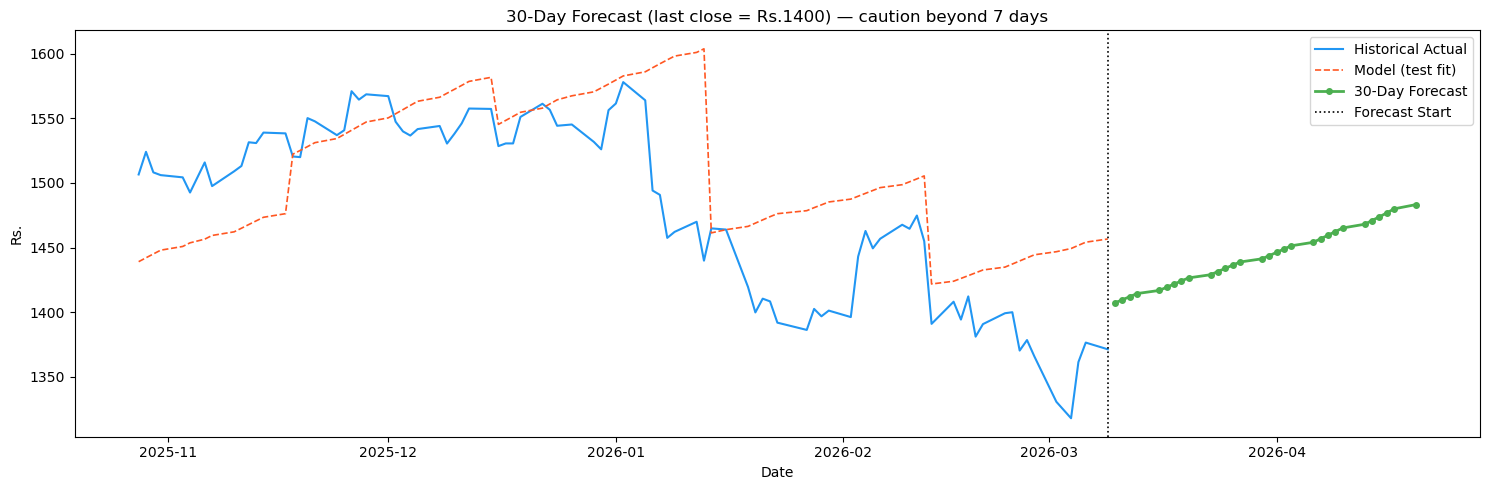

Saved: outputs/results/future_forecast_30days.csv
      Date  Predicted_Close  Pct_vs_last
2026-03-10          1407.17         0.55
2026-03-11          1409.57         0.72
2026-03-12          1411.97         0.89
2026-03-13          1414.37         1.06
2026-03-16          1416.77         1.23
2026-03-17          1419.17         1.41
2026-03-18          1421.60         1.58
2026-03-19          1424.04         1.75
2026-03-20          1426.47         1.93
2026-03-23          1428.93         2.10
2026-03-24          1431.41         2.28
2026-03-25          1433.85         2.45
2026-03-26          1436.31         2.63
2026-03-27          1438.77         2.81
2026-03-30          1441.26         2.98
2026-03-31          1443.74         3.16
2026-04-01          1446.25         3.34
2026-04-02          1448.80         3.52
2026-04-03          1451.35         3.70
2026-04-06          1454.06         3.90
2026-04-07          1456.79         4.09
2026-04-08          1459.55         4.29
2026-04

In [16]:
### Cell 15 — 30-Day Forecast + Save CSV

def forecast_future(model, last_sequence, f_scaler, t_scaler,
                    avg_log_volume, avg_hl_ratio, n_days=30):
    seq = last_sequence.copy()
    close_idx    = FEATURE_COLS.index("Close")
    close_buffer = list(f_scaler.inverse_transform(seq[0])[:, close_idx])
    lr_buffer    = []; predicted_closes = []

    for _ in range(n_days):
        pred_scaled = model.predict(seq, verbose=0)
        pred_lr     = float(t_scaler.inverse_transform(pred_scaled)[0, 0])
        prev_close  = close_buffer[-1]
        new_close   = prev_close * np.exp(pred_lr)
        close_buffer.append(new_close); lr_buffer.append(pred_lr)
        predicted_closes.append(new_close)
        cb = close_buffer
        raw_row = np.array([[
            prev_close,
            new_close * (1 + avg_hl_ratio/2),
            new_close * (1 - avg_hl_ratio/2),
            new_close, np.exp(avg_log_volume), pred_lr, avg_hl_ratio,
            (new_close - prev_close) / prev_close,
            (new_close - cb[-6])  if len(cb) > 5  else 0.0,
            (new_close - cb[-11]) if len(cb) > 10 else 0.0,
            float(np.std(lr_buffer[-9:]+[pred_lr])) if len(lr_buffer) > 0 else 0.0,
            (np.mean(cb[-5:])/np.mean(cb[-20:])) if len(cb) >= 20 else 1.0,
            avg_log_volume,
        ]])
        seq = np.roll(seq, -1, axis=1)
        seq[0, -1, :] = f_scaler.transform(raw_row)[0]
    return predicted_closes


avg_log_volume       = float(test_df["Log_Volume"].mean())
avg_hl_ratio         = float(test_df["HL_Ratio"].mean())
last_known_raw_close = float(test_df["Close"].iloc[-1])

future_preds = forecast_future(
    final_model, X_test[-1:], final_f_sc, final_t_sc,
    avg_log_volume, avg_hl_ratio, n_days=30)
future_dates = pd.bdate_range(start=test_dates[-1] + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(15,5))
plt.plot(test_dates[-90:], y_test_true[-90:], label="Historical Actual", color="#2196F3", lw=1.5)
plt.plot(test_dates[-90:], y_test_pred[-90:], label="Model (test fit)",  color="#FF5722", lw=1.2, ls="--")
plt.plot(future_dates, future_preds,           label="30-Day Forecast",   color="#4CAF50", lw=2, marker="o", ms=4)
plt.axvline(test_dates[-1], color="black", ls=":", lw=1.2, label="Forecast Start")
plt.title(f"30-Day Forecast (last close = Rs.{last_known_raw_close:.0f}) — caution beyond 7 days")
plt.xlabel("Date"); plt.ylabel("Rs."); plt.legend()
plt.tight_layout(); plt.savefig("outputs/plots/12_future_forecast_30d.png", dpi=150); plt.show()

forecast_df = pd.DataFrame({
    "Date"            : future_dates,
    "Predicted_Close" : [round(p, 2) for p in future_preds],
    "Pct_vs_last"     : [round((p/last_known_raw_close-1)*100, 2) for p in future_preds],
})
forecast_df.to_csv("outputs/results/future_forecast_30days.csv", index=False)
print("Saved: outputs/results/future_forecast_30days.csv")
print(forecast_df.to_string(index=False))
